# SegNet: A Deep Convolutional Encoder-Decoder Architecture for Image Segmentation

In [ ]:
import zipfile
import torch
import numpy as np
from train import get_dataset, train_model
from model import SegNet
from FCN_2014.utils import compute_metrics, show_predictions, list_show_annotation_torch

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

print(torch.__version__)

Using device: cuda
2.6.0+cu124


## Prepare the Dataset: CamVid

In [ ]:
# download the dataset (zipped file)
!wget https://storage.googleapis.com/learning-datasets/fcnn-dataset.zip  -O /tmp/fcnn-dataset.zip

--2025-03-30 21:41:34--  https://storage.googleapis.com/learning-datasets/fcnn-dataset.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 125577577 (120M) [application/zip]
Saving to: ‘/tmp/fcnn-dataset.zip’

/tmp/fcnn-dataset.z 100%[===================>] 119.76M   167MB/s    in 0.7s    

2025-03-30 21:41:35 (167 MB/s) - ‘/tmp/fcnn-dataset.zip’ saved [125577577/125577577]



In [ ]:
# extract the downloaded dataset to a local directory: /tmp/fcnn
local_zip = "/tmp/fcnn-dataset.zip"
with zipfile.ZipFile(local_zip, "r") as zip_ref:
    zip_ref.extractall("/tmp/fcnn")

In [ ]:
# show directories downloaded
!ls /tmp/fcnn/dataset1/

annotations_prepped_test  annotations_prepped_train  images_prepped_test  images_prepped_train


In [ ]:
class_names = [
    "sky",
    "building",
    "column/pole",
    "road",
    "vegetation",
    "side walk",
    "traffic light",
    "fence",
    "vehicle",
    "pedestrian",
    "byciclist",
    "void",
]

In [ ]:
def get_config():
    return {
        "batch_size": 64,
        "img_size" : 224,
        "num_epochs": 160,
        "lr": 1e-3,
        "model_folder": "/weights",
        "model_basename": "segnet3_model_",
        "preload": "149",
        "experiment_name": "/runs/segnet3_model",
    }

### Visualization

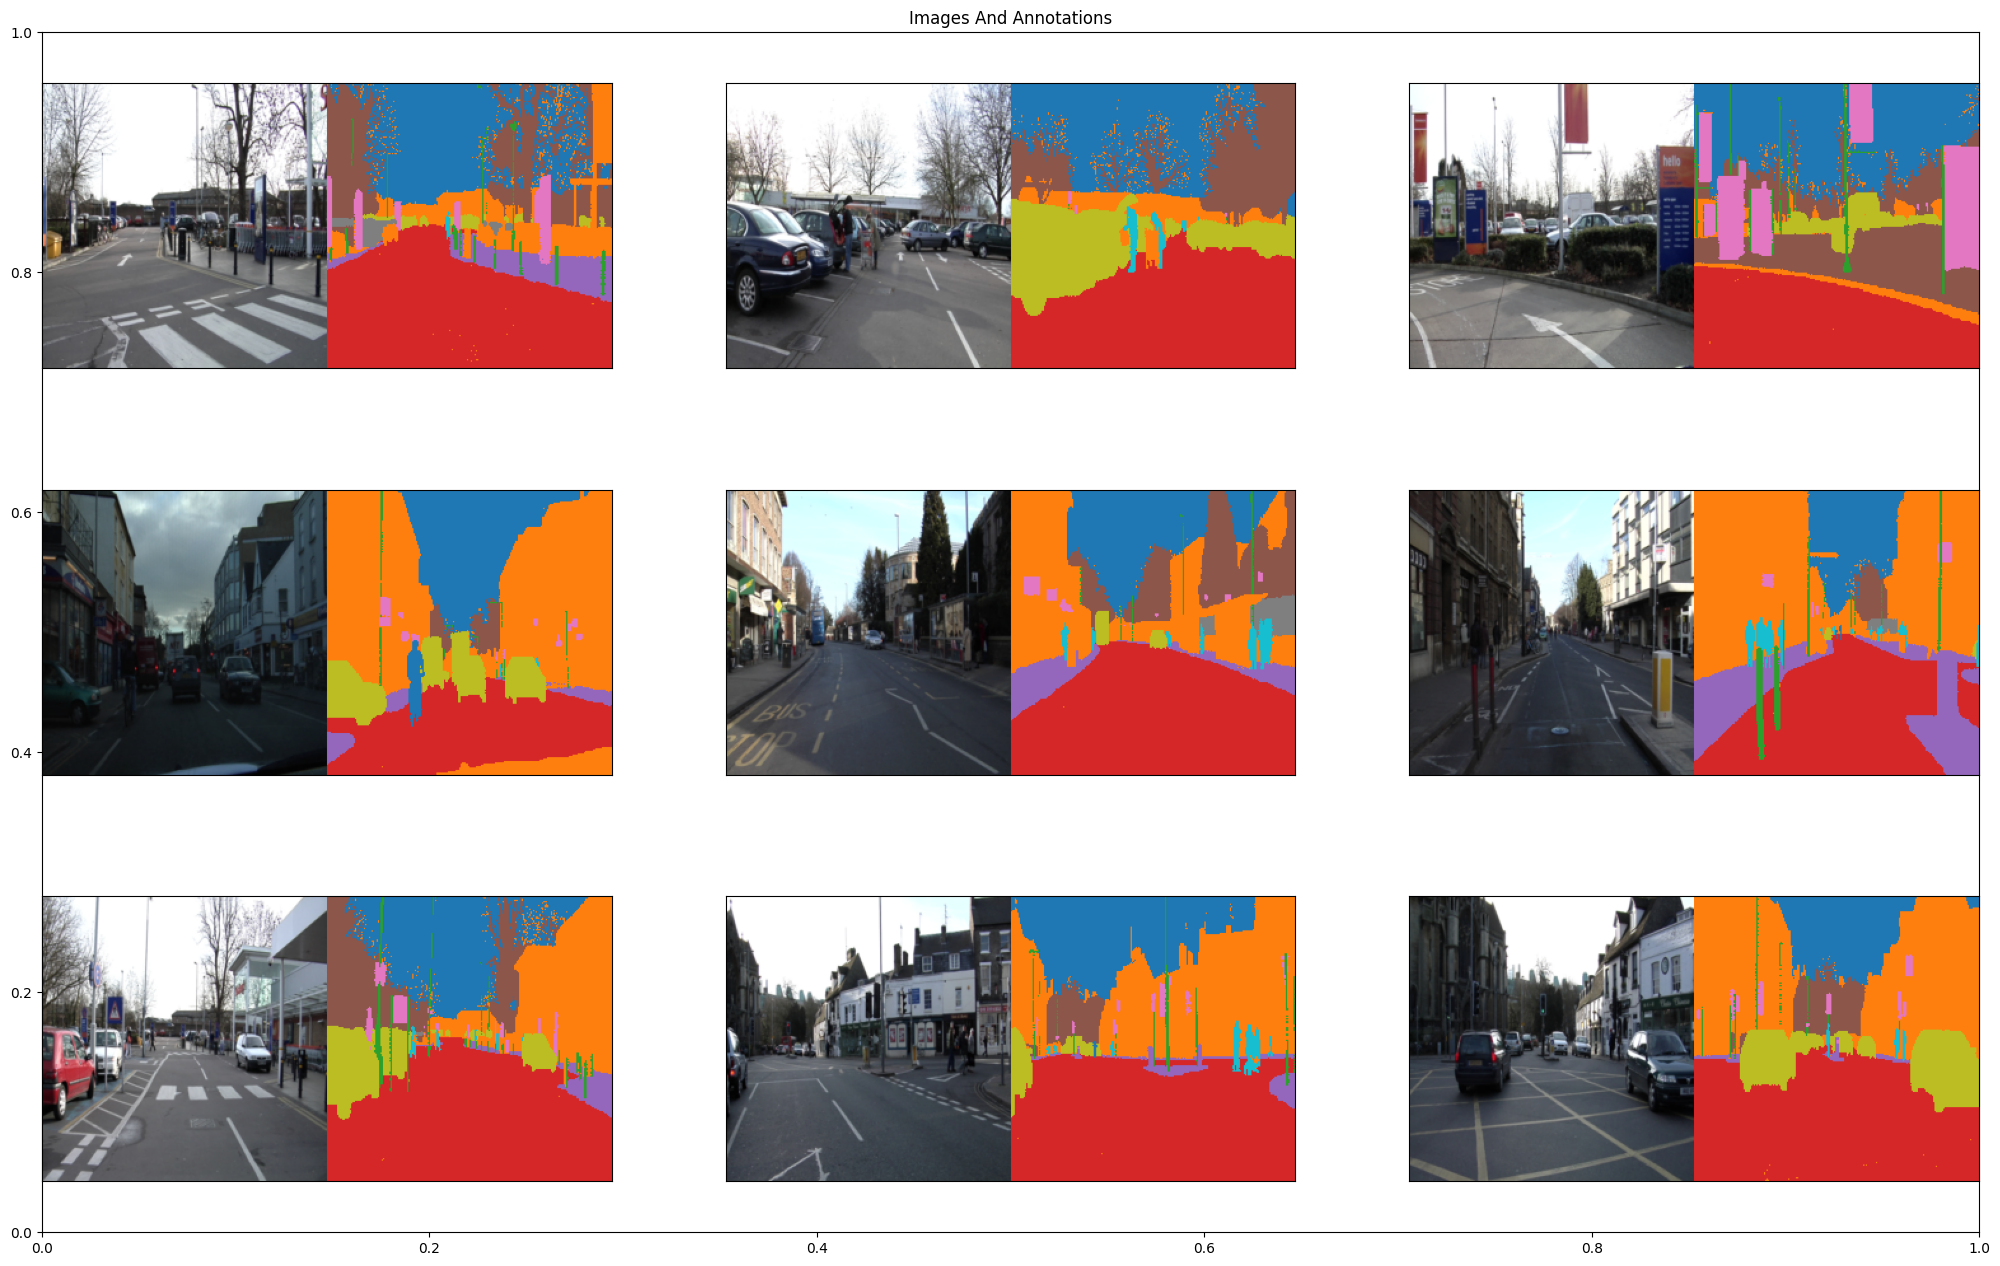

In [ ]:
config = get_config()
train_loader, _ = get_dataset(config)

list_show_annotation_torch(train_loader)

## Define the Model

In [ ]:
model = SegNet(num_classes=12)
model

SegNet(
  (encoder): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4):

## Train the Model

In [134]:
train_model(model, config)

Using device: cuda
Preloading model: /weights/segnet3_model_149.pt


Epoch [159/160]: 100%|██████████| 6/6 [00:13<00:00,  2.28s/it, accuracy=79.48, loss=1.841]


## Evaluate the Model

In [135]:
import itertools

y_true_images = []
y_true_segments = []
subset_size = 32

_, test_loader = get_dataset(config)

for image, annotation in itertools.islice(test_loader, subset_size // config["batch_size"] + 1):
    # remove batch dimension
    y_true_images.extend(image.cpu().numpy())
    y_true_segments.extend(torch.argmax(annotation, dim=1).cpu().numpy())

y_true_images = np.array(y_true_images)[:subset_size]
y_true_segments = np.array(y_true_segments)[:subset_size]

In [136]:
model.eval()
with torch.no_grad():
    all_predictions = []
    for batch_idx, (data, target) in enumerate(test_loader):
        data, target = data.to(device), target.to(device)
        output = model(data)
        # get class with max probability
        predictions = torch.argmax(output, dim=1)
        all_predictions.append(predictions.cpu().numpy())

results = np.concatenate(all_predictions, axis=0)

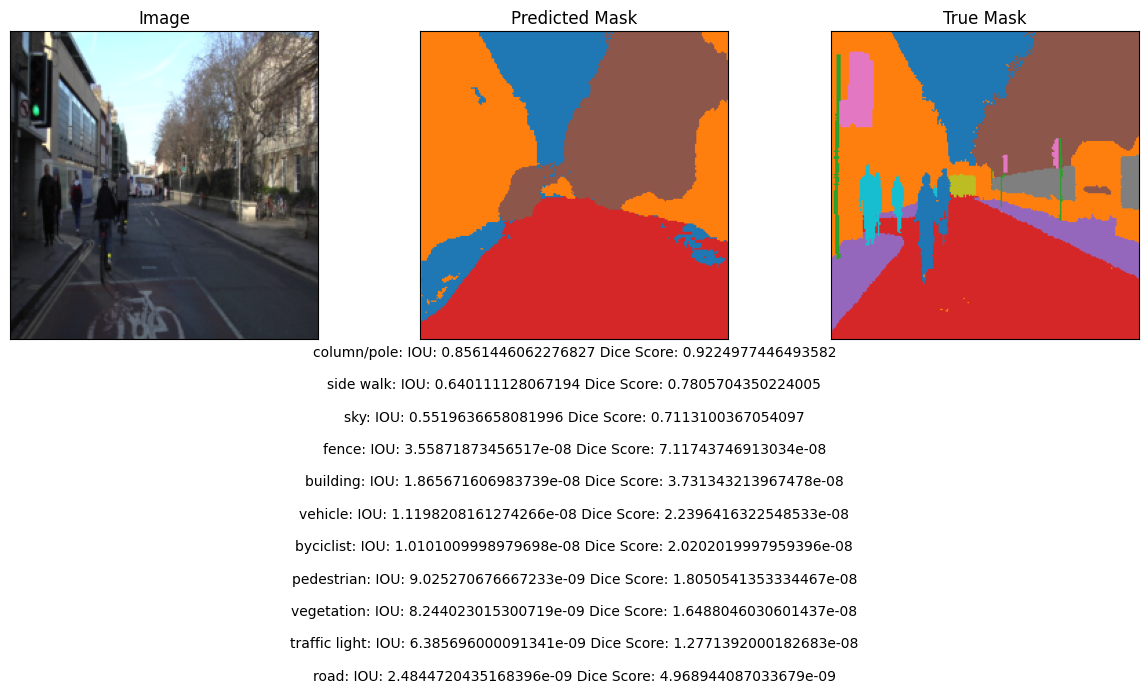

In [137]:
integer_slider = 0

iou, dice_score = compute_metrics(y_true_segments[integer_slider], results[integer_slider])

show_predictions(y_true_images[integer_slider], [results[integer_slider], y_true_segments[integer_slider]], ["Image", "Predicted Mask", "True Mask"], iou, dice_score, image_ordering="channels_first")

In [138]:
cls_wise_iou, cls_wise_dice_score = compute_metrics(y_true_segments, results[:subset_size])

In [139]:
for idx, iou in enumerate(cls_wise_iou):
    spaces = " " * (13-len(class_names[idx]) + 2)
    print(f"{class_names[idx]}{spaces}{iou}")

sky            0.7028547221818403
building       1.117693080230588e-09
column/pole    0.8676645713995184
road           7.107522601416707e-11
side walk      0.734541600431992
vegetation     6.35404752423812e-10
traffic light  1.9899309490000734e-10
fence          3.7012362115251923e-10
vehicle        9.135757345938464e-10
pedestrian     2.8134143588753617e-10
byciclist      3.616374944446559e-10


In [140]:
# print the dice score for each class
for idx, dice_score in enumerate(cls_wise_dice_score):
  spaces = " " * (13-len(class_names[idx]) + 2)
  print(f"{class_names[idx]}{spaces}{dice_score}")

sky            0.8255016861200656
building       2.235386160461176e-09
column/pole    0.9291438994938938
road           1.4215045202833414e-10
side walk      0.846957605700407
vegetation     1.270809504847624e-09
traffic light  3.979861898000147e-10
fence          7.402472423050385e-10
vehicle        1.827151469187693e-09
pedestrian     5.626828717750723e-10
byciclist      7.232749888893118e-10
